In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import re

import nltk
import spacy

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

print("All libraries loaded")

All libraries loaded


In [3]:
import pandas as pd

df = pd.read_csv("../data/customer_support_tickets.csv")

df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [6]:
print(df.shape)
df.info()
df.columns

(8469, 17)
<class 'pandas.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   str    
 2   Customer Email                8469 non-null   str    
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   str    
 5   Product Purchased             8469 non-null   str    
 6   Date of Purchase              8469 non-null   str    
 7   Ticket Type                   8469 non-null   str    
 8   Ticket Subject                8469 non-null   str    
 9   Ticket Description            8469 non-null   str    
 10  Ticket Status                 8469 non-null   str    
 11  Resolution                    2769 non-null   str    
 12  Ticket Priority               8469 non-null   str    
 13  Tic

Index(['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age',
       'Customer Gender', 'Product Purchased', 'Date of Purchase',
       'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status',
       'Resolution', 'Ticket Priority', 'Ticket Channel',
       'First Response Time', 'Time to Resolution',
       'Customer Satisfaction Rating'],
      dtype='str')

In [9]:
df["text"] = (
    df["Ticket Subject"].fillna("") +
    " " +
    df["Ticket Description"].fillna("")
)

df[["text"]].head()
df["Ticket Type"].value_counts()
df["Ticket Priority"].value_counts()

Ticket Priority
Medium      2192
Critical    2129
High        2085
Low         2063
Name: count, dtype: int64

In [10]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/codespace/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /home/codespace/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [12]:
import spacy

nlp = spacy.load("en_core_web_sm")

print("spaCy model loaded")

spaCy model loaded


In [13]:
import re
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-zA-Z\s]", "", text)

    doc = nlp(text)

    tokens = []

    for token in doc:
        if token.text not in stop_words:
            tokens.append(token.lemma_)

    return " ".join(tokens)

In [14]:
df["clean_text"] = df["text"].apply(clean_text)

df[["text", "clean_text"]].head()

,text,clean_text
0,Product setup I'm having an issue with the {pr...,product setup issue productpurchased please as...
1,Peripheral compatibility I'm having an issue w...,peripheral compatibility issue productpurchase...
2,Network problem I'm facing a problem with my {...,network problem face problem productpurchase p...
3,Account access I'm having an issue with the {p...,account access issue productpurchased please a...
4,Data loss I'm having an issue with the {produc...,data loss issue productpurchased please assist...


In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [16]:
vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df["clean_text"])

print("Shape of X:", X.shape)

Shape of X: (8469, 5000)


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [18]:
y = df["Ticket Type"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (6775, 5000)
Test size: (1694, 5000)


In [19]:
model_type = LogisticRegression(max_iter=1000)

model_type.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [20]:
from sklearn.metrics import classification_report

y_pred = model_type.predict(X_test)

print(classification_report(y_test, y_pred))

                      precision    recall  f1-score   support

     Billing inquiry       0.15      0.10      0.12       357
Cancellation request       0.18      0.19      0.18       327
     Product inquiry       0.18      0.18      0.18       316
      Refund request       0.22      0.25      0.23       345
     Technical issue       0.20      0.22      0.21       349

            accuracy                           0.19      1694
           macro avg       0.18      0.19      0.18      1694
        weighted avg       0.18      0.19      0.18      1694



In [21]:
vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2)  # IMPORTANT (unigrams + bigrams)
)

X = vectorizer.fit_transform(df["text"])  # use RAW text now

In [22]:
from sklearn.naive_bayes import MultinomialNB

In [23]:
y = df["Ticket Type"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = MultinomialNB()
model.fit(X_train, y_train)

print("Naive Bayes model trained")

Naive Bayes model trained


In [24]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

                      precision    recall  f1-score   support

     Billing inquiry       0.17      0.07      0.10       357
Cancellation request       0.20      0.20      0.20       327
     Product inquiry       0.15      0.14      0.14       316
      Refund request       0.19      0.27      0.22       345
     Technical issue       0.22      0.28      0.25       349

            accuracy                           0.19      1694
           macro avg       0.19      0.19      0.18      1694
        weighted avg       0.19      0.19      0.18      1694



In [25]:
y_priority = df["Ticket Priority"]

In [26]:
from sklearn.model_selection import train_test_split

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X,
    y_priority,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train_p.shape)
print("Testing samples:", X_test_p.shape)

Training samples: (6775, 10000)
Testing samples: (1694, 10000)


In [27]:
from sklearn.naive_bayes import MultinomialNB

priority_model = MultinomialNB()

priority_model.fit(X_train_p, y_train_p)

print("Priority model trained successfully")

Priority model trained successfully


In [28]:
from sklearn.metrics import classification_report

y_pred_p = priority_model.predict(X_test_p)

print(classification_report(y_test_p, y_pred_p))

              precision    recall  f1-score   support

    Critical       0.24      0.31      0.27       411
        High       0.26      0.25      0.25       409
         Low       0.22      0.16      0.18       415
      Medium       0.27      0.28      0.28       459

    accuracy                           0.25      1694
   macro avg       0.25      0.25      0.25      1694
weighted avg       0.25      0.25      0.25      1694



In [29]:
sample_tickets = [
    "My payment was deducted twice from my account",
    "The app crashes every time I open it",
    "I want to cancel my subscription immediately"
]

sample_vec = vectorizer.transform(sample_tickets)

print("Ticket Type Predictions:")
print(model.predict(sample_vec))

print("\nPriority Predictions:")
print(priority_model.predict(sample_vec))

Ticket Type Predictions:
['Product inquiry' 'Billing inquiry' 'Billing inquiry']

Priority Predictions:
['Critical' 'Critical' 'Critical']


In [30]:
import pickle
import os

os.makedirs("models", exist_ok=True)

In [31]:
pickle.dump(model, open("models/ticket_type_model.pkl", "wb"))
pickle.dump(priority_model, open("models/priority_model.pkl", "wb"))
pickle.dump(vectorizer, open("models/vectorizer.pkl", "wb"))

print("All models saved successfully")

All models saved successfully


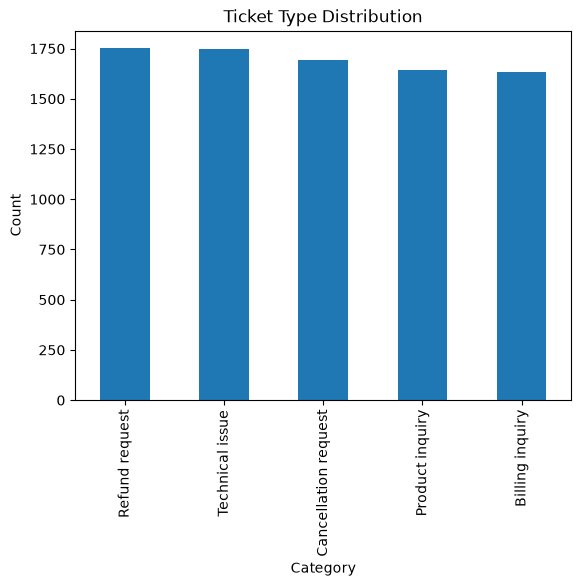

In [33]:
import matplotlib.pyplot as plt

df["Ticket Type"].value_counts().plot(kind="bar")
plt.title("Ticket Type Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

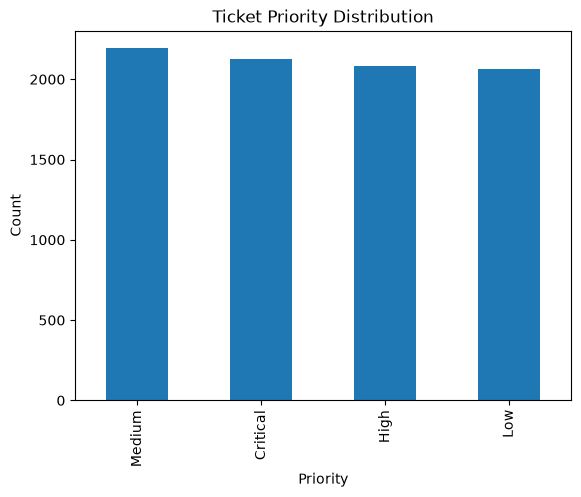

In [34]:
df["Ticket Priority"].value_counts().plot(kind="bar")
plt.title("Ticket Priority Distribution")
plt.xlabel("Priority")
plt.ylabel("Count")
plt.show()